<a href="https://colab.research.google.com/github/alyssaplayer/BU_OMDS_APlayerRepo/blob/main/DX799_Capstone_OList_(Marketing)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Required Libraries


In [ ]:
import kagglehub
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#Loading the Dataset
#Brazilian E-Commerce Public Dataset by Olist
#Kaggle

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

df_raw = path

#to save the dataset:
#df.to_csv("olist_df.csv", index=False)

dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset downloaded to:", dataset_path)

# List all downloaded CSV files
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
print(f"\nFiles available ({len(csv_files)} CSVs):")
for f in sorted(csv_files):
    print(f"  {f}")

# ── Cell 3: Load each CSV into a named DataFrame ──────────────────────────────
import pandas as pd

orders        = pd.read_csv(os.path.join(dataset_path, "olist_orders_dataset.csv"))
order_items   = pd.read_csv(os.path.join(dataset_path, "olist_order_items_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(dataset_path, "olist_order_reviews_dataset.csv"))
customers     = pd.read_csv(os.path.join(dataset_path, "olist_customers_dataset.csv"))
products      = pd.read_csv(os.path.join(dataset_path, "olist_products_dataset.csv"))
sellers       = pd.read_csv(os.path.join(dataset_path, "olist_sellers_dataset.csv"))
payments      = pd.read_csv(os.path.join(dataset_path, "olist_order_payments_dataset.csv"))
geo           = pd.read_csv(os.path.join(dataset_path, "olist_geolocation_dataset.csv"))
product_names = pd.read_csv(os.path.join(dataset_path, "product_category_name_translation.csv"))

print("All datasets loaded successfully.")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset downloaded to: /kaggle/input/brazilian-ecommerce

Files available (9 CSVs):
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv
All datasets loaded successfully.


In [ ]:
#merging all the pertinent datasets in the relational database together
import pandas as pd

# 2. Build the master DataFrame
# Start with orders and add items
df = pd.merge(orders, order_items, on='order_id', how='left')

# Add the review data (adding in the customer satisfaction data)
df = pd.merge(df, order_reviews, on='order_id', how='left')

# Add the customer location/demographic data
df = pd.merge(df, customers, on='customer_id', how='left')

# Check the resulting dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   order_item_id                  113314 non-null  float64
 9   product_id                     113314 non-null  object 
 10  seller_id                      113314 non-null  object 
 11  shipping_limit_date            113314 non-null  object 
 12  price                         

In [ ]:
#EDA
display(df.head(), df.describe())



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


,order_item_id,price,freight_value,review_score,customer_zip_code_prefix
count,113314.000000,113314.000000,113314.000000,113131.000000,114092.000000
mean,1.198528,120.478701,19.979428,4.016998,35105.227308
std,0.707016,183.279678,15.783227,1.400074,29868.300916
min,1.000000,0.850000,0.000000,1.000000,1003.000000
25%,1.000000,39.900000,13.080000,4.000000,11250.000000
50%,1.000000,74.900000,16.260000,5.000000,24320.000000
75%,1.000000,134.900000,21.150000,5.000000,59022.000000
max,21.000000,6735.000000,409.680000,5.000000,99990.000000


In [ ]:
#EDA - Checking Available Data in the Dataset
# Unique values per column
print("Unique values per column:")
display(df.nunique().to_frame("unique_count"))

# Null values per column
print("\nNull values per column:")
display(df.isnull().sum().to_frame("null_count"))

# Duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Unique values per column:


,unique_count
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459
order_item_id,21
product_id,32951



Null values per column:


,null_count
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,162
order_delivered_carrier_date,1980
order_delivered_customer_date,3253
order_estimated_delivery_date,0
order_item_id,778
product_id,778



Number of duplicate rows: 0


# Feature Engineering


In [ ]:
#1. Date/Time Columns
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# 2. Numeric Features from Dates
# Days from purchase to actual delivery (key satisfaction driver)
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

#86400 seconds = 1 day

# Early or late dependent on expected delivery date (negative = early, positive = late)
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# Days from purchase to approval
df['approval_days'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

# How quickly the seller handed to carrier
df['carrier_handoff_days'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.total_seconds() / 86400

# How long the customer waited for a review response
df['review_response_days'] = (
    df['review_answer_timestamp'] - df['review_creation_date']
).dt.total_seconds() / 86400

# 3. Encode order_status (ordinal — reflects fulfilment progress)
status_order = {
    'created': 0, 'approved': 1, 'processing': 2, 'invoiced': 3,
    'shipped': 4, 'delivered': 5, 'unavailable': -1, 'canceled': -2
}
df['order_status_enc'] = df['order_status'].map(status_order)

#  4. Encode customer_state (frequency encoding — avoids 27 dummies)
state_freq = df['customer_state'].value_counts(normalize=True)
df['customer_state_freq'] = df['customer_state'].map(state_freq)

#  5. Has review comment? (binary signal)
df['has_comment'] = df['review_comment_message'].notna().astype(int)

#  6. Drop rows missing the target (review_score)
df_model = df.dropna(subset=['review_score']).copy()

#  7. Final feature matrix for modelling
feature_cols = [
    'price', 'freight_value', 'order_item_id',
    'delivery_days', 'delivery_delay_days',
    'approval_days', 'carrier_handoff_days', 'review_response_days',
    'order_status_enc', 'customer_state_freq', 'has_comment'
]



/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


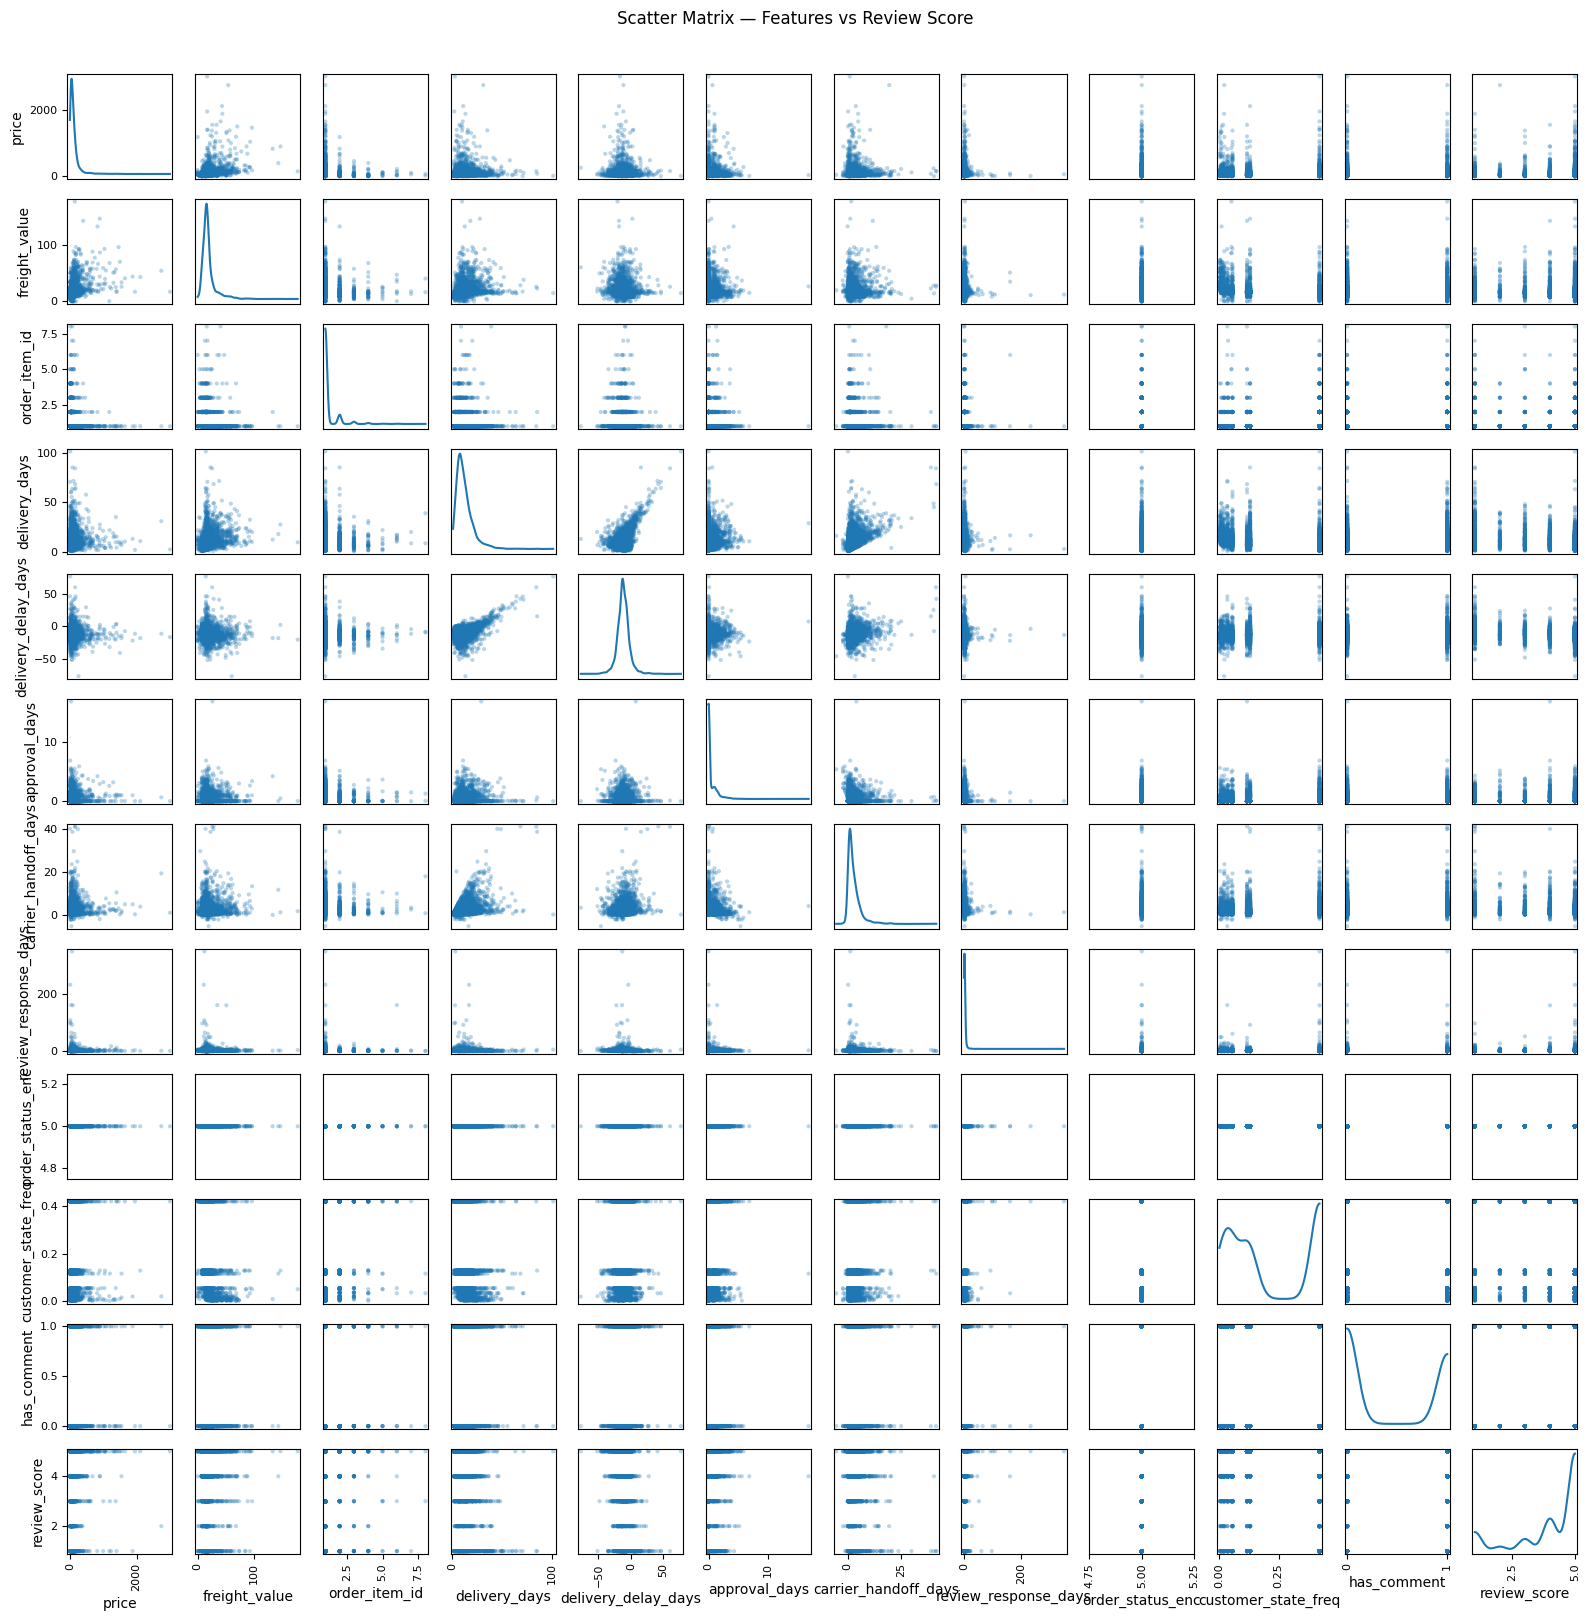

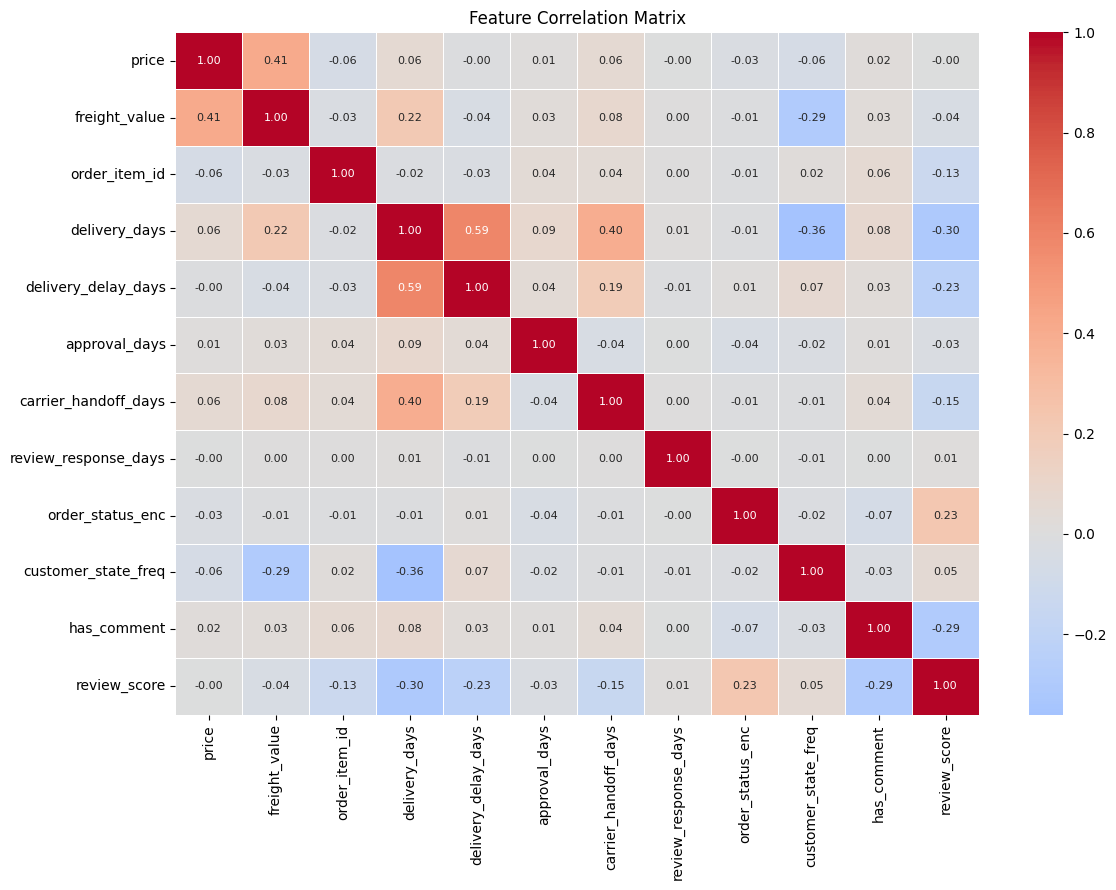

In [ ]:
#Correlation Matrix
import seaborn as sns
corr_matrix = df_model[feature_cols + ['review_score']].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
#Train / Test / Split
from sklearn.model_selection import train_test_split

df_model = df_model.dropna(subset=feature_cols).copy()

X = df_model[feature_cols]
y = df_model['review_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Modelling dataset: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Modelling dataset: 109,996 rows × 11 features
Train: 87,996 rows | Test: 22,000 rows

Target distribution:
review_score
1.0    12578
2.0     3699
3.0     9242
4.0    21179
5.0    63298
Name: count, dtype: int64


# W1: Linear Regression

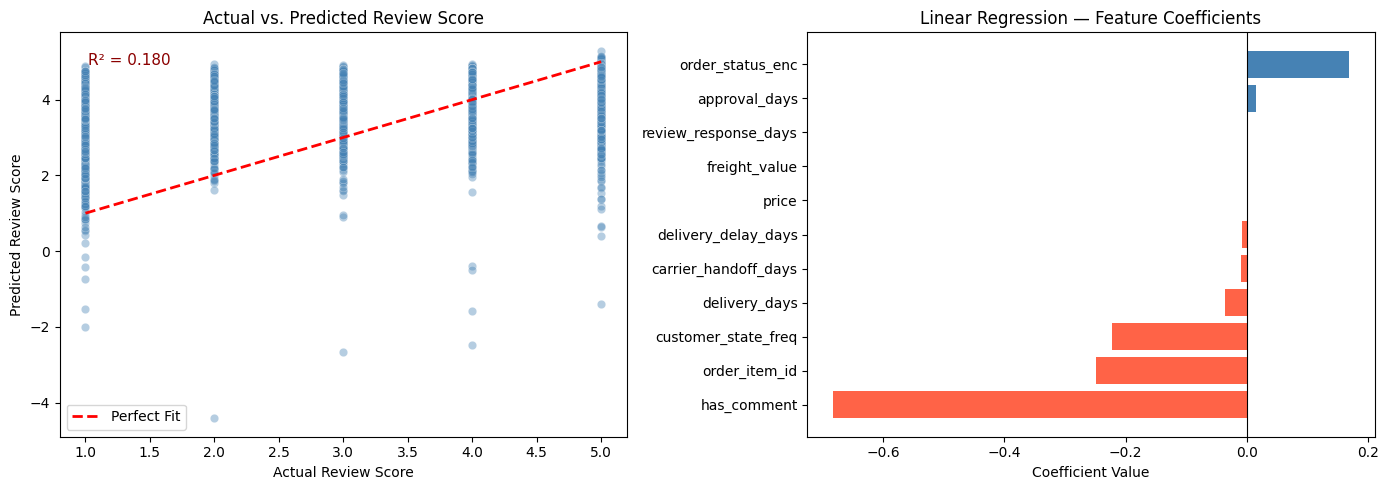

R²:   0.1797
RMSE: 1.2134


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Review Score')
axes[0].set_ylabel('Predicted Review Score')
axes[0].set_title('Actual vs. Predicted Review Score')
axes[0].legend()
axes[0].annotate(f'R² = {r2_score(y_test, y_pred):.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11, color='darkred')

# Feature coefficients
coef_df = pd.Series(model.coef_, index=feature_cols).sort_values()
axes[1].barh(coef_df.index, coef_df.values, color=['tomato' if v < 0 else 'steelblue' for v in coef_df.values])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Linear Regression — Feature Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Week 2: Lasso, Ridge, and Elastic Net Regression

In [ ]:
#Lasso Regression
from sklearn.linear_model import Lasso

# Initialize the model (alpha acts as the lambda regularization parameter)
# By default, alpha=1.0
lasso_model = Lasso(alpha=1.0)

# Fit the model to your training data
lasso_model.fit(X_train, y_train)

# Make predictions
predictions = lasso_model.predict(X_test)

In [ ]:
#Ridge Regression
from sklearn.linear_model import Ridge

# Initialize the model
# By default, alpha=1.0
ridge_model = Ridge(alpha=1.0)

# Fit the model to your training data
ridge_model.fit(X_train, y_train)

# Make predictions
predictions = ridge_model.predict(X_test)

#use GridSearch CV to test lambda

In [ ]:
#Elastic Net Regression
from sklearn.linear_model import ElasticNet

# Initialize the model
# alpha controls the overall strength of the penalty
# l1_ratio controls the mix (l1_ratio=1.0 is pure Lasso, 0.0 is pure Ridge)
# Default l1_ratio is generally 0.5 (an even split)
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Fit the model to your training data
elastic_net_model.fit(X_train, y_train)

# Make predictions
predictions = elastic_net_model.predict(X_test)

In [ ]:

for name, m in [("Lasso", lasso_model), ("Ridge", ridge_model), ("ElasticNet", elastic_net_model)]:
    preds = m.predict(X_test)
    print(f"{name:12s} | R²: {r2_score(y_test, preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

Lasso        | R²: 0.0873 | RMSE: 1.2799
Ridge        | R²: 0.1797 | RMSE: 1.2134
ElasticNet   | R²: 0.0933 | RMSE: 1.2758


# W3: Forward / Backward Selection

In [ ]:
#forward and backward selection, PCR, and PLSR.

#W4

In [ ]:
#logistic regression and feature scaling

#W5: Support Vector Machines

In [ ]:
#or Week 5, include concepts such as support vector machines, the kernel trick, and regularization for support vector machine